In [19]:
import matplotlib.colors as mcolors
import matplotlib.animation as ma
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
import pandas as pd
import numpy as np
import numba as nb
import imageio
import os
import shutil

randomSeed = 100

%matplotlib inline
%config InlineBackend.figure_format = "retina"

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "new", plt.cm.hsv(np.linspace(0, 1, 256)) * 0.85, N=256
)
# colors = ["#95D3A2", "#FFFFBF", "#F79051", ]
colors = ["#5657A4", "#95D3A2", "#FFFFBF", "#F79051", "#A30644"]
cmap = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors)
cmap_r = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors[::-1])

@nb.njit
def colors_idx(phaseTheta):
    return np.floor(256 - phaseTheta / (2 * np.pi) * 256).astype(np.int32)

import seaborn as sns

sns.set_theme(
    style="ticks", 
    font_scale=1.1, rc={
    'figure.figsize': (6, 5),
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.5,
    "lines.linewidth": 1.5,
    'text.color': '#000000',
    'figure.titleweight': "bold",
    'xtick.color': '#000000',
    'ytick.color': '#000000'
})

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['animation.ffmpeg_path'] = "/opt/conda/bin/ffmpeg"

from main import *
from multiprocessing import Pool
import pandas as pd

SAVE_PATH = r"F:\MS_ExperimentData\general"
# SAVE_PATH = r"D:\MS_ExperimentData\general"

In [38]:
class CLV(PatternFormation):
    def __init__(self, 
                 chemoAlpha: float, partiDiffD: float,
                 prodRateK: float, sinkRateMu: float, chemoDiffDc: float,
                 boundaryLength: float = 20.0, cellNumInLine: int = 200, agentsNum: int=1000, 
                 dt: float=0.01, shotsnaps: int = 10,
                 tqdm: bool = False, savePath: str = None,
                 randomSeed: int = 10, overWrite: bool = False) -> None:
        
        np.random.seed(randomSeed)

        self.randomSeed = randomSeed
        self.cellNumInLine = cellNumInLine
        self.dx = boundaryLength / (cellNumInLine - 1)
        self.boundaryLength = boundaryLength
        self.agentsNum = agentsNum
        self.prodRateK = prodRateK
        self.chemoDiffDc = chemoDiffDc
        self.dt = dt
        self.chemoAlpha = chemoAlpha
        self.partiDiffD = partiDiffD

        self.shotsnaps = shotsnaps
        self.tqdm = tqdm
        self.savePath = savePath
        self.counts = 0
        self.overWrite = overWrite
        self.mu = sinkRateMu

        self.positionX = np.random.random((agentsNum, 2)) * boundaryLength
        self.c = np.random.rand(cellNumInLine, cellNumInLine)

        self.temp = dict()
        # The order of variable definitions has a dependency relationship
        self.temp["ocsiIdx"] = (self.positionX / self.dx).round().astype(int)
        self.temp["grad"] = self.localGradient
        self.temp["dotC"] = self.dotC
        self.temp["dotR"] = self.dotR

    def plot(self, ax: plt.Axes = None):
        if ax is None:
            _, ax = plt.subplots(figsize=(5, 5))
        # ax.scatter(
        #     self.positionX[:, 0], self.positionX[:, 1],
        #     color="#9BD5D5", s=50
        # )
        unitDirection = self.temp["dotR"] / np.linalg.norm(self.temp["dotR"], axis=1, keepdims=True)
        ax.quiver(
            self.positionX[:, 0], self.positionX[:, 1],
            unitDirection[:, 0], unitDirection[:, 1],
            color="#49B2B2", angles="xy", scale_units="xy"
        )
        ax.set_xlim(0, self.boundaryLength)
        ax.set_ylim(0, self.boundaryLength)
    
    @property
    def nablaC(self):
        return np.array([ 
            (np.roll(self.c, -1, axis=0) - np.roll(self.c, 1, axis=0)),
            (np.roll(self.c, -1, axis=1) - np.roll(self.c, 1, axis=1))
        ]).transpose(1, 2, 0) / (2 * self.dx)

    @staticmethod
    @nb.njit
    def _product_c(dx: float, cellNumInLine: int, ocsiIdx: np.ndarray, productRateK0: np.ndarray):
        counts = np.zeros((cellNumInLine, cellNumInLine), dtype=np.float64)
        for idx in ocsiIdx:
            counts[idx[0], idx[1]] = counts[idx[0], idx[1]] + 1
        # particle number density = counts / (dx^2)
        return counts /(dx**2) * productRateK0
    
    @property
    def productC(self):
        return self._product_c(
            dx=self.dx,
            cellNumInLine=self.cellNumInLine, 
            ocsiIdx=self.temp["ocsiIdx"][:],
            productRateK0=self.prodRateK
        )

    @property
    def localGradient(self):
        localGradC = self.nablaC[self.temp["ocsiIdx"][:, 0], self.temp["ocsiIdx"][:, 1]]
        return self.chemoAlpha * localGradC

    def _nabla2(self, c):
        center = -c
        direct_neighbors = 0.20 * (
            np.roll(c, 1, axis=0)
            + np.roll(c, -1, axis=0)
            + np.roll(c, 1, axis=1)
            + np.roll(c, -1, axis=1)
        )
        diagonal_neighbors = 0.05 * (
            np.roll(np.roll(c, 1, axis=0), 1, axis=1)
            + np.roll(np.roll(c, -1, axis=0), 1, axis=1)
            + np.roll(np.roll(c, -1, axis=0), -1, axis=1)
            + np.roll(np.roll(c, 1, axis=0), -1, axis=1)
        )

        out_array = center + direct_neighbors + diagonal_neighbors
        return out_array / (self.dx ** 2)
    
    @property
    def diffusionC(self):
        return self._nabla2(self.c) * self.chemoDiffDc
    
    @property
    def dotC(self):
        return self.productC + self.diffusionC - self.mu * self.c
    
    @property
    def partiDiffusion(self):
        if self.partiDiffD == 0:
            return np.zeros_like(self.positionX)
        # D is the diffusion coefficient and dt is the time step.
        noise = np.random.normal(0, np.sqrt(2 * self.partiDiffD * self.dt), size=self.positionX.shape)
        return noise
    
    @property
    def dotR(self):
        return self.localGradient + self.partiDiffusion

    def update(self):
        self.temp["ocsiIdx"] = (self.positionX / self.dx).round().astype(int)
        self.temp["dotC"] = self.dotC
        self.temp["dotR"] = self.dotR

        self.positionX = np.mod(
            self.positionX + self.temp["dotR"] * self.dt, 
            self.boundaryLength
        )
        self.c += self.temp["dotC"] * self.dt
        self.c[self.c < 0] = 0

        self.counts += 1
    
    def append(self):
        # if self.counts % self.shotsnaps == 0:
        #     self.plot()
        #     plt.show()
        if self.store is not None:
            if self.counts % self.shotsnaps != 0:
                return
            self.store.append(key="positionX", value=pd.DataFrame(self.positionX))
            self.store.append(key="c", value=pd.DataFrame(self.c))

    def __str__(self) -> str:
                
        name =  (
            f"{self.__class__.__name__}_"
            f"alpha{self.chemoAlpha:.1f},D{self.partiDiffD:.3f},"
            f"k{self.prodRateK:.3f},mu{self.mu:.3f},Dc{self.chemoDiffDc:.3f},"
            f"L{self.boundaryLength:.1f},cN{self.cellNumInLine},N{self.agentsNum},"
            f"dt{self.dt:.3f},s{self.shotsnaps},"
            f"seed{self.randomSeed}"
        )
        
        return name

In [80]:
self = model = CLV(
    chemoAlpha=10.0, partiDiffD=0.0,
    prodRateK=-0.4 / 100, sinkRateMu=-0.1, chemoDiffDc=0.1,
    boundaryLength=20.0, cellNumInLine=200, agentsNum=1000,
    dt=0.01, shotsnaps=1000,
    tqdm=True, savePath=None, randomSeed=10, overWrite=False
)

In [81]:
model.run(10000)

100%|███████████████████████████████████████████████████████| 10000/10000 [00:07<00:00, 1417.60it/s]


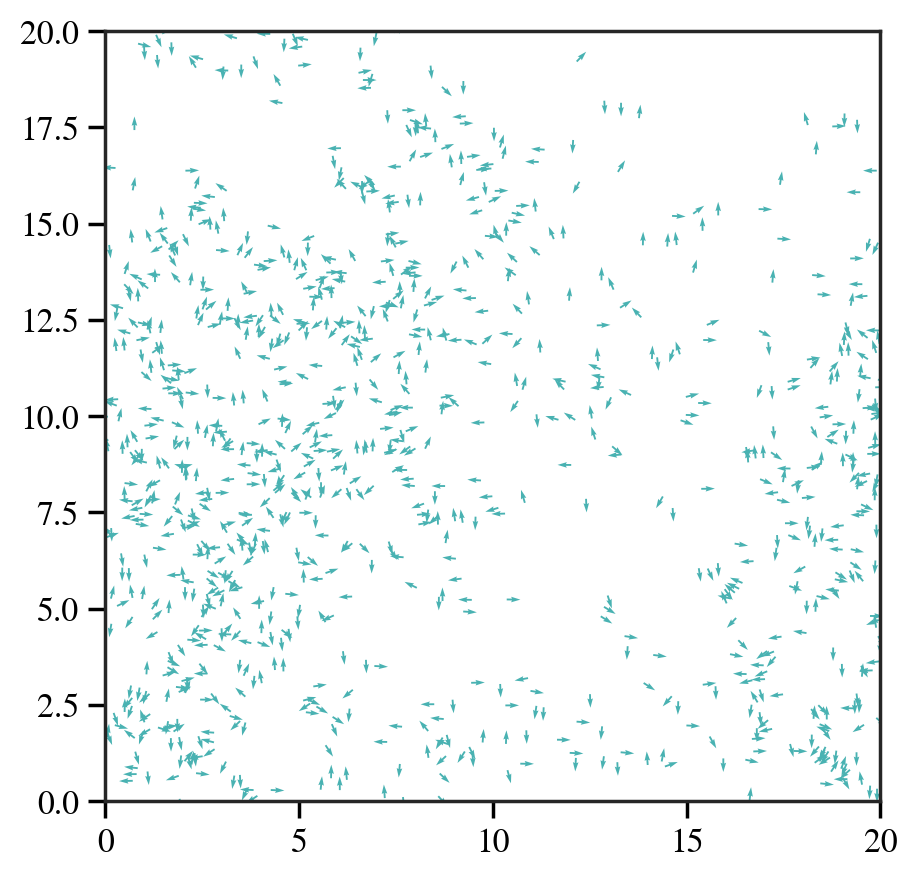

In [82]:
model.plot()

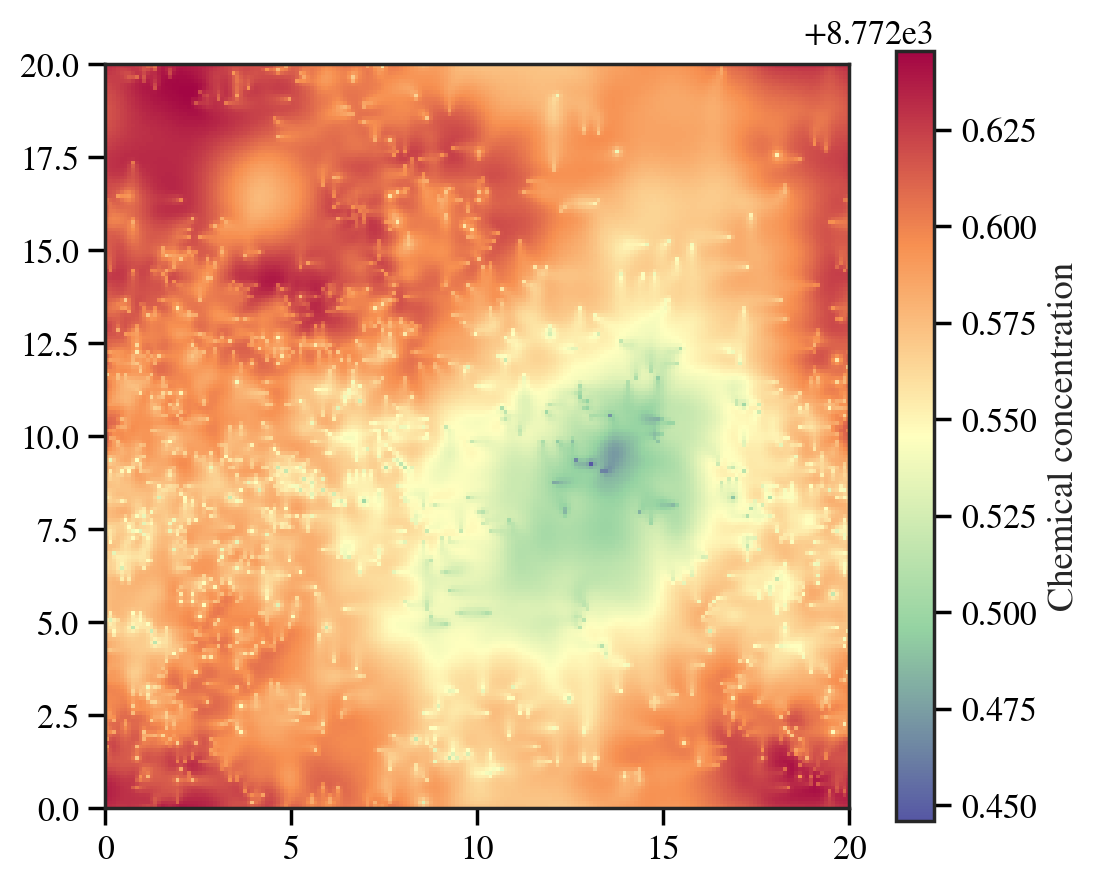

In [83]:
ax = None

if ax is None:
    _, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(self.c.T, origin='lower', 
                extent=[0, self.boundaryLength, 0, self.boundaryLength],
                cmap=cmap, alpha=1)
plt.colorbar(im, ax=ax, label='Chemical concentration')

(0.0, 200.0)

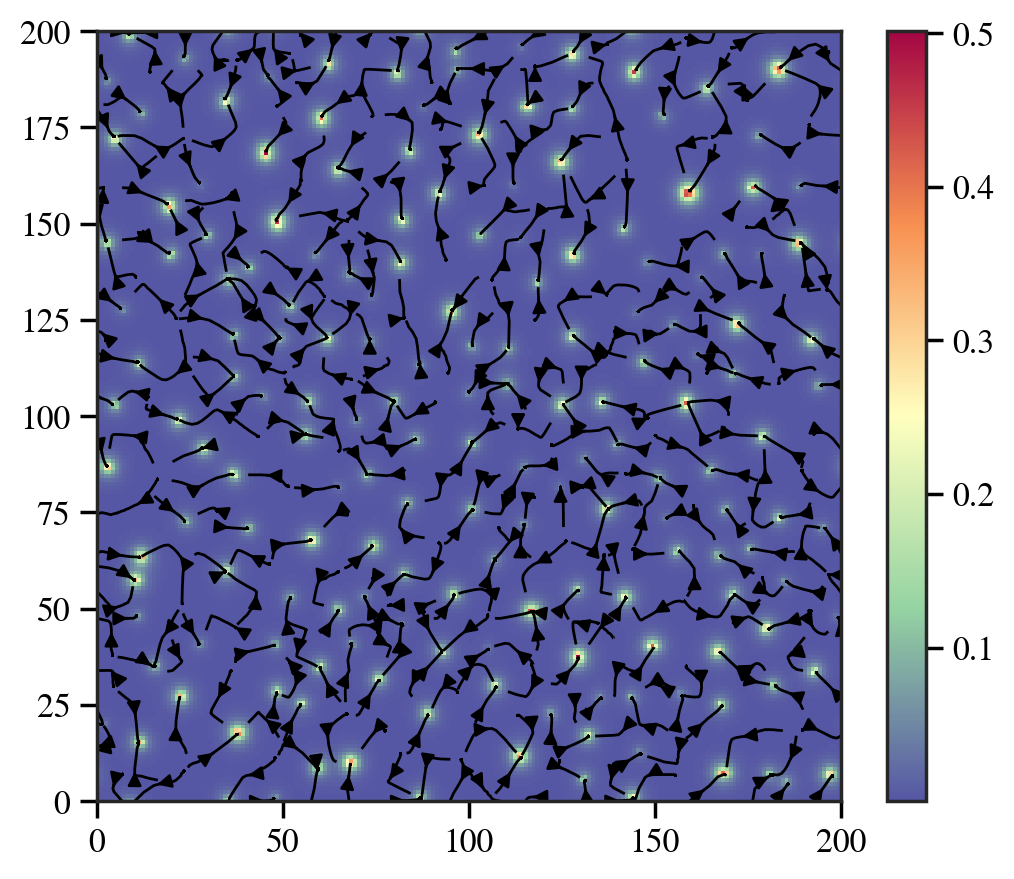

In [71]:
adjMulti = model.cellNumInLine / model.boundaryLength
# cPosition = model.cPosition.reshape(model.cellNumInLine, model.cellNumInLine, 2)
cPosition = np.array(list(product(np.linspace(0, model.boundaryLength, model.cellNumInLine), repeat=2))).reshape(model.cellNumInLine, model.cellNumInLine, 2)
X = cPosition[:, :, 0].T * adjMulti
Y = cPosition[:, :, 1].T * adjMulti
c = model.c.copy().T
U = np.roll(c, -1, axis=1) - np.roll(c, 1, axis=1)
V = np.roll(c, -1, axis=0) - np.roll(c, 1, axis=0)
plt.streamplot(X, Y, U, V, color="black", linewidth=1, density=2)

plt.pcolor(model.c.T, cmap=cmap)
plt.colorbar()
plt.xlim(0, model.cellNumInLine)
plt.ylim(0, model.cellNumInLine)